# Customer Segmentation Analysis

This notebook prepares customer data, segments customers with K-Means clustering, and compares the resulting groups.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Data

In [2]:
data = pd.read_csv(r"D:\ML\internship\majorProject\marketing_campaign.csv", sep='\t')
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

## 2. Clean and Engineer Features

In [3]:
df = data.drop(['ID','Z_Revenue','Response'], axis=1)
df["TotalAcceptedCmp"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] + 
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

In [4]:
df.drop(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5'], axis=1, inplace=True)

In [5]:
# df.info()
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,88,88,3,8,10,4,7,0,3,0
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,1,6,2,1,1,2,5,0,3,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,21,42,1,8,2,10,4,0,3,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,3,5,2,2,0,4,6,0,3,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,27,15,5,5,3,6,5,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,...,118,247,2,9,3,4,5,0,3,0
2236,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,...,0,8,7,8,2,5,7,0,3,1
2237,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,12,24,1,2,3,13,6,0,3,1
2238,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,...,30,61,2,6,5,10,3,0,3,0


In [6]:
df["Education"].unique()
df.drop_duplicates()
if pd.api.types.is_datetime64_any_dtype(df["Year_Birth"]):
    birth_year = df["Year_Birth"].dt.year
else:
    birth_year = pd.to_numeric(df["Year_Birth"], errors="coerce")
df["Age"] = 2026 - birth_year
df.drop(columns="Year_Birth", inplace=True)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp,Age
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,88,3,8,10,4,7,0,3,0,69
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,6,2,1,1,2,5,0,3,0,72
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,42,1,8,2,10,4,0,3,0,61
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,5,2,2,0,4,6,0,3,0,42
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,15,5,5,3,6,5,0,3,0,45


In [7]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["TotalSpending"] = df[spending_cols].sum(axis=1)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp,Age,TotalSpending
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,3,8,10,4,7,0,3,0,69,1617
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,2,1,1,2,5,0,3,0,72,27
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,1,8,2,10,4,0,3,0,61,776
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,2,2,0,4,6,0,3,0,42,53
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,5,5,3,6,5,0,3,0,45,422


In [8]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

In [9]:
df["customerTenure"] = (
    df["Dt_Customer"].max() - df["Dt_Customer"]
)

df.drop(columns="Dt_Customer",inplace=True)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp,Age,TotalSpending,customerTenure
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,8,10,4,7,0,3,0,69,1617,663 days
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,1,1,2,5,0,3,0,72,27,113 days
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,8,2,10,4,0,3,0,61,776,312 days
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,2,0,4,6,0,3,0,42,53,139 days
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,5,3,6,5,0,3,0,45,422,161 days


In [11]:
df.describe()["Age"]

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

In [10]:
categorical_cols = df.select_dtypes(include=["object","string"]).columns
numerical_cols = df.select_dtypes(include="number").columns

In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)
values = encoder.fit_transform(df[categorical_cols])
names = encoder.get_feature_names_out(categorical_cols)

df[names] = values
df.drop(columns=categorical_cols,inplace=True)
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [12]:
df["Income"] = df.Income.fillna(df["Income"].mean())

## 3. Prepare Data for Clustering

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Exclude timedelta columns because MinMaxScaler only accepts numeric values.
numerical_cols = df.select_dtypes(include="number", exclude="timedelta").columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,0.084832,0.0,0.0,0.585859,0.425318,0.442211,0.316522,0.664093,0.334601,0.243094,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.067095,0.5,0.5,0.383838,0.007368,0.005025,0.003478,0.007722,0.003802,0.016575,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.105097,0.0,0.0,0.262626,0.285332,0.246231,0.073623,0.428571,0.079848,0.116022,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.037471,0.5,0.0,0.262626,0.007368,0.020101,0.011594,0.038610,0.011407,0.013812,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.085065,0.5,0.0,0.949495,0.115874,0.216080,0.068406,0.177606,0.102662,0.041436,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [14]:
x = df[["Income","TotalSpending"]].fillna(df[["Income","TotalSpending"]].mean())

## 4. Build Customer Segments

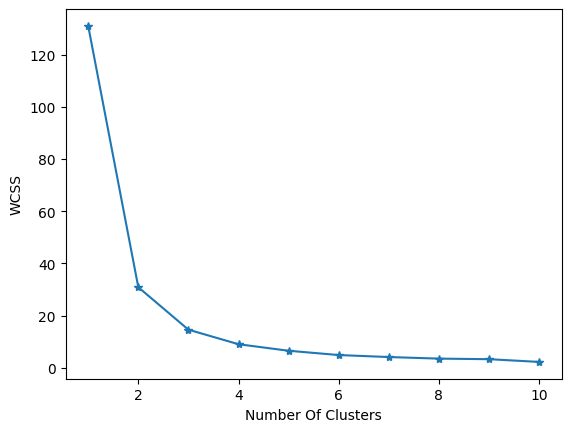

In [15]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker="*")
plt.xlabel("Number Of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=1,
    n_init=10
)
kmeans.fit(x)
df.loc[x.index, "Cluster"] = kmeans.labels_

## 5. Understand Customer Behaviour

In [19]:
df[numerical_cols] = scaler.inverse_transform(df[numerical_cols])

cluster_summary = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    AverageAge=("Age", "mean"),
    AverageIncome=("Income", "mean"),
    AverageSpending=("TotalSpending", "mean")
).round(1)

cluster_summary

,Customers,AverageAge,AverageIncome,AverageSpending
Cluster,,,,
0.0,609,59.7,65579.2,915.1
1.0,1266,55.8,38473.1,151.1
2.0,365,57.9,77778.5,1666.9


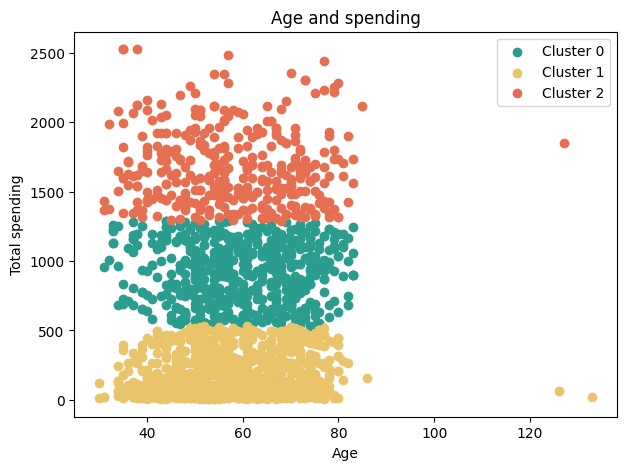

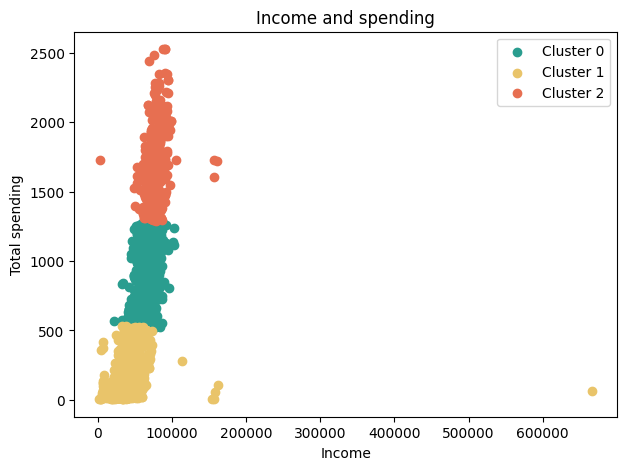

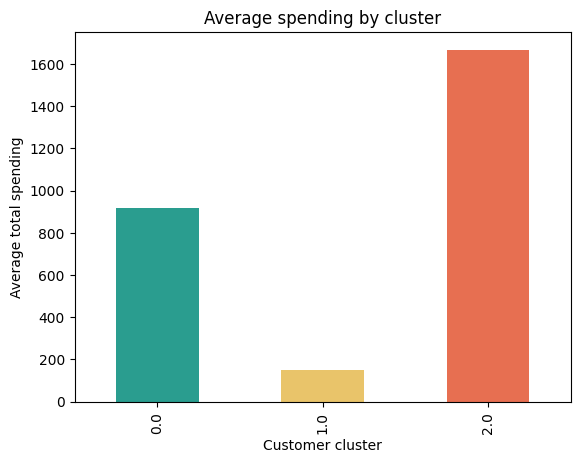

In [ ]:
cluster0 = df[df["Cluster"] == 0]
cluster1 = df[df["Cluster"] == 1]
cluster2 = df[df["Cluster"] == 2]

plt.figure(figsize=(7, 5))
plt.scatter(cluster0["Age"], cluster0["TotalSpending"], color="#2a9d8f", label="Cluster 0")
plt.scatter(cluster1["Age"], cluster1["TotalSpending"], color="#e9c46a", label="Cluster 1")
plt.scatter(cluster2["Age"], cluster2["TotalSpending"], color="#e76f51", label="Cluster 2")
plt.title("Age and spending")
plt.xlabel("Age")
plt.ylabel("Total spending")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(cluster0["Income"], cluster0["TotalSpending"], color="#2a9d8f", label="Cluster 0")
plt.scatter(cluster1["Income"], cluster1["TotalSpending"], color="#e9c46a", label="Cluster 1")
plt.scatter(cluster2["Income"], cluster2["TotalSpending"], color="#e76f51", label="Cluster 2")
plt.title("Income and spending")
plt.xlabel("Income")
plt.ylabel("Total spending")
plt.legend()
plt.show()

average_spending = df.groupby("Cluster")["TotalSpending"].mean()
average_spending.plot(kind="bar", color=["#2a9d8f", "#e9c46a", "#e76f51"])
plt.title("Average spending by cluster")
plt.xlabel("Customer cluster")
plt.ylabel("Average total spending")
plt.show()

## Conclusion

Customers with higher incomes generally spend more, while customers with lower incomes spend less. Cluster 1 contains the lowest-spending customers, Cluster 0 contains medium-spending customers, and Cluster 2 contains the highest-spending customers. Age is spread across all three groups, so it does not strongly explain spending behavior. The main difference between customers is their income and total spending.